# Self-Reflection RAG (Autonomous RAG)

Implements the Self-Reflection RAG workflow using LangChain + LangGraph.

Flow: Retrieve -> Generate -> Self-Reflect -> (loop back with revised query OR end)

Knowledge source: `RAG_FineTuning_Agents_Interview_Project_Cost_Management.txt` (loaded via `TextLoader`)

In [21]:
pip install -q langchain langchain-openai langchain-community langgraph faiss-cpu python-dotenv


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
from dotenv import load_dotenv

load_dotenv()  # reads OPENAI_API_KEY from .env

from typing import TypedDict, Optional, Literal

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, END

## 1. Load the document with TextLoader

In [23]:
FILE_PATH = "RAG_FineTuning_Agents_Interview_Project_Cost_Management.txt"

loader = TextLoader(FILE_PATH, encoding="utf-8")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print(docs[0].page_content[:300])

Loaded 1 document(s)
RAG, RAG FINE-TUNING, AI AGENTS & PROJECT COST MANAGEMENT

INTERVIEW PREPARATION GUIDE
Level: Intermediate to Advanced
Focus: AI/LLM Engineering, RAG Systems, Fine-Tuning, Agents, and Cost Management

TABLE OF CONTENTS
-----------------



## 2. Chunk the document

In [6]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
)
chunks = splitter.split_documents(docs)

print(f"Total chunks: {len(chunks)}")

Total chunks: 44


## 3. Build embeddings + FAISS vector store

In [7]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

## 4. LLM

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 5. RAG Reflection State

Holds the query, retrieved docs, generated answer, reflection verdict and retry count.

In [9]:
class RAGReflectionState(TypedDict):
    question: str
    original_question: str
    documents: list
    generation: str
    verdict: str
    reason: str
    retries: int

## 6. Self-reflection structured output schema

In [10]:
class ReflectionResult(BaseModel):
    verdict: Literal["sufficient", "insufficient"] = Field(
        description="sufficient if the answer is clear, complete and accurate; else insufficient"
    )
    reason: str = Field(description="short reason for the verdict")
    revised_question: Optional[str] = Field(
        default=None,
        description="a better search query to use if verdict is insufficient, else null"
    )

reflection_llm = llm.with_structured_output(ReflectionResult)

## 7. Nodes: Retrieve, Generate, Self-Reflect

In [11]:
def retrieve_node(state: RAGReflectionState) -> RAGReflectionState:
    query = state["question"]
    docs = retriever.invoke(query)
    return {"documents": docs}

In [12]:
generate_prompt = ChatPromptTemplate.from_template(
    """Answer the question using only the context below.
If the context is not enough, say what is missing.

Context:
{context}

Question: {question}

Answer:"""
)

generate_chain = generate_prompt | llm | StrOutputParser()

def generate_node(state: RAGReflectionState) -> RAGReflectionState:
    context = "\n\n".join(d.page_content for d in state["documents"])
    answer = generate_chain.invoke({"context": context, "question": state["question"]})
    return {"generation": answer}

In [13]:
reflect_prompt = ChatPromptTemplate.from_template(
    """You are evaluating an AI-generated answer for clarity, completeness and accuracy.

Original question: {original_question}
Answer given: {generation}

Judge if the answer is sufficient. If not, suggest a revised search query
that would help retrieve better context for the original question."""
)

def self_reflect_node(state: RAGReflectionState) -> RAGReflectionState:
    result = reflection_llm.invoke(
        reflect_prompt.format(
            original_question=state["original_question"],
            generation=state["generation"],
        )
    )
    update = {"verdict": result.verdict, "reason": result.reason, "retries": state["retries"] + 1}
    if result.verdict == "insufficient" and result.revised_question:
        update["question"] = result.revised_question
    return update

## 8. Routing logic

Loop back to retrieval if the reflection verdict is `insufficient`, up to a max of 2 retries.
Otherwise end.

In [14]:
MAX_RETRIES = 2

def decide_next(state: RAGReflectionState) -> str:
    if state["verdict"] == "sufficient":
        return "end"
    if state["retries"] >= MAX_RETRIES:
        return "end"
    return "retry"


## 9. Build the LangGraph

In [15]:
graph = StateGraph(RAGReflectionState)

graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)
graph.add_node("reflect", self_reflect_node)

graph.set_entry_point("retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "reflect")

graph.add_conditional_edges(
    "reflect",
    decide_next,
    {"retry": "retrieve", "end": END},
)

app = graph.compile()

## 10. (Optional) Visualize the graph

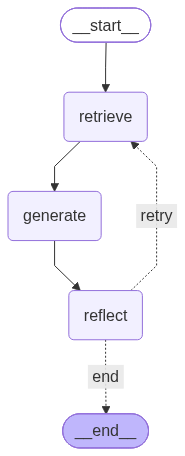

In [16]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization needs extra deps, skipping:", e)

## 11. Run it

In [17]:
def run_query(question: str):
    initial_state = {
        "question": question,
        "original_question": question,
        "documents": [],
        "generation": "",
        "verdict": "",
        "reason": "",
        "retries": 0,
    }
    final_state = app.invoke(initial_state)
    print("Question:", question)
    print("Retries used:", final_state["retries"])
    print("Final verdict:", final_state["verdict"], "-", final_state["reason"])
    print("\nAnswer:\n", final_state["generation"])
    return final_state

In [18]:
_ = run_query("What is RAG and when should it be used instead of fine-tuning?")

Question: What is RAG and when should it be used instead of fine-tuning?
Retries used: 1
Final verdict: sufficient - The answer clearly explains what RAG is, how it works, and provides specific scenarios when it should be used instead of fine-tuning, addressing both clarity and completeness.

Answer:
 RAG is an architecture that retrieves relevant external knowledge and provides it to a language model (LLM) as context before generation. It should be used instead of fine-tuning when knowledge changes frequently, documents are private, citations are required, or knowledge needs to be updated without retraining. Fine-tuning is better suited for changing behavior, ensuring consistent output formats, improving performance on specialized tasks, or when domain-specific language/style is important.


In [19]:
_ = run_query("How do you estimate the cost of a production RAG system?")

Question: How do you estimate the cost of a production RAG system?
Retries used: 2
Final verdict: insufficient - The answer does not provide any specific information or guidance on estimating the cost of a production RAG system, making it unclear and incomplete.

Answer:
 The context does not provide specific information on the key factors and methodologies for estimating the cost of a production RAG system. It mentions "Cost Estimation Framework" in the table of contents, but does not elaborate on the details. Additional information on cost factors, methodologies, or examples would be needed to answer the question fully.


In [20]:
_ = run_query("What should I check first if my RAG system gives poor answers?")

Question: What should I check first if my RAG system gives poor answers?
Retries used: 1
Final verdict: sufficient - The answer clearly outlines steps to evaluate both retrieval and generation quality in a RAG system, providing specific areas to investigate for each issue. It is complete and accurate in addressing the original question.

Answer:
 Start with evaluation and separate retrieval quality from generation quality. Check whether the correct evidence is retrieved. If not, investigate chunking, embeddings, query transformation, hybrid search, metadata filters, and reranking. If the evidence is correct but the answer is wrong, investigate prompt construction, context ordering, model behavior, and grounding.
